In [1]:
# Colores ANSI
RESET = "\033[0m"
BOLD = "\033[1m"

RED = "\033[31m"
GREEN = "\033[32m"
YELLOW = "\033[33m"
BLUE = "\033[34m"
MAGENTA = "\033[35m"
CYAN = "\033[36m"

BG_RED = "\033[41m"
BG_GREEN = "\033[42m"
BG_YELLOW = "\033[43m"
BG_BLUE = "\033[44m"

def color_masked(sentence):
    """Resalta <mask> en amarillo."""
    return sentence.replace("<mask>", f"{BG_YELLOW}{BOLD}<mask>{RESET}")

def color_ort_errors(annotated):
    """
    Convierte:
        <err t=ort>he</err>
    en:
        [he] coloreado según tipo
    """
    import re

    def repl(match):
        tipo = match.group(1)
        palabra = match.group(2)

        if tipo == "ort":
            col = RED
        elif tipo == "reord":
            col = BLUE
        elif tipo == "add":
            col = GREEN
        else:
            col = MAGENTA

        return f"{col}[{palabra}]{RESET}"

    return re.sub(r"<err t=(.*?)>(.*?)</err>", repl, annotated)


In [2]:
import json
from pathlib import Path
from tabulate import tabulate

import json
from pathlib import Path
from tabulate import tabulate

def _short(text, n=180):
    if text is None:
        return f"{RED}None{RESET}"
    if not isinstance(text, str):
        return text
    return text if len(text) <= n else text[:n] + "..."

def load_results(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def pretty_print_results(data):
    print(f"\n{BOLD}{CYAN}==============================")
    print("      RESULTADOS DEL MODELO")
    print("==============================\n" + RESET)

    for task, contenido in data.items():
        print(f"\n\n{BOLD}{MAGENTA}########################################")
        print(f"### TAREA: {task.upper()}")
        print("########################################\n" + RESET)

        media = contenido["media"]
        ejemplos = contenido["ejemplo"]  

        # -------------------------
        # MÉTRICAS GLOBALES
        # -------------------------
        print(f"{BOLD}▶ MÉTRICAS GLOBALES{RESET}\n")
        table = [[k, v] for k, v in media.items()]
        print(tabulate(table, headers=["Métrica", "Valor"], floatfmt=".4f"))
        print("\n")

        # -------------------------
        # EJEMPLOS
        # -------------------------
        print(f"{BOLD}▶ EJEMPLOS{RESET}\n")

        # Si no es lista, lo convertimos en lista
        if not isinstance(ejemplos, list):
            ejemplos = [ejemplos]

        for idx, ej in enumerate(ejemplos):
            print(f"\n{BOLD}--- Ejemplo {idx+1} ---{RESET}")

            # ============================
            # TRADUCCIÓN
            # ============================
            if task == "traduccion":
                print(f"{CYAN}source:{RESET}     {_short(ej['source'])}")
                print(f"{CYAN}reference:{RESET}  {_short(ej['reference'])}")
                print(f"{CYAN}translated:{RESET} {_short(ej['translated'])}")
                print(f"{YELLOW}BLEU:{RESET} {ej['BLEU']:.4f}   {YELLOW}chrF:{RESET} {ej['chrF']:.4f}")

            # ============================
            # ROUND TRIP
            # ============================
            elif task == "round_trip":
                print(f"{CYAN}intermediate_language:{RESET} {ej['intermediate_language']}")
                print(f"{CYAN}source:{RESET}       {_short(ej['source'])}")
                print(f"{CYAN}intermediate:{RESET} {_short(ej['intermediate'])}")
                print(f"{CYAN}translated:{RESET}   {_short(ej['return'])}")
                print(f"{YELLOW}BLEU:{RESET} {ej['BLEU']:.4f}   {YELLOW}chrF:{RESET} {ej['chrF']:.4f}")

            # ============================
            # CALIDAD LENGUA
            # ============================
            elif task == "calidad_lengua":
                print(ej)
                print(f"{CYAN}text:{RESET} {_short(ej['text'])}")
                for m in ["ttr", "entropy", "ngram_overlap", "freq_target", "freq_comparison", "calidad"]:
                    print(f"{YELLOW}{m}:{RESET} {ej[m]}")

            # ============================
            # VOCABULARIO
            # ============================
            elif task == "vocabulario":
                print(f"{CYAN}original:{RESET} {_short(ej['original'])}")
                print(f"{CYAN}masked_sentence:{RESET} {color_masked(_short(ej['masked_sentence']))}")
                print(f"{CYAN}missing_word:{RESET} {GREEN}{ej['missing_word']}{RESET}")

                r = ej["resultado"]
                print(f"{BOLD}resultado:{RESET}")
                print(f"  predicted: {_short(r['predicted'])}")
                print(f"  accuracy: {r['accuracy']}")
                print(f"  accuracy_lower: {r['accuracy_lower']}")
                print(f"  levenshtein: {r['levenshtein']}")

            # ============================
            # ORTOGRAFÍA
            # ============================
            elif task == "ortografia":
                print(f"{CYAN}original:{RESET} {_short(ej['original'])}")
                print(f"{CYAN}annotated:{RESET} {color_ort_errors(_short(ej['annotated']))}")
                print(f"{CYAN}n_errors:{RESET} {ej['n_errors']}")

                r = ej["resultado"]
                print(f"{BOLD}resultado:{RESET}")
                print(f"  incorrect: {_short(r['incorrect'])}")
                print(f"  corrected: {_short(r['corrected'])}")
                print(f"  BLEU: {r['BLEU']:.4f}   chrF: {r['chrF']:.4f}")
                print(f"  Levenshtein: {r['Levenshtein']}")
                print(f"  errores_totales: {r['errores_totales']}")
                print(f"  errores_corregidos: {r['errores_corregidos']}")
                print(f"  errores_no_corregidos: {r['errores_no_corregidos']}")
                print(f"  errores_nuevos: {r['errores_nuevos']}")
                print(f"  precision: {r['precision']:.4f}")
                print(f"  recall: {r['recall']:.4f}")
                print(f"  F1: {r['F1']:.4f}")

                print("  errores_detalle:")
                for tipo, palabra in r["errores_detalle"]:
                    col = RED if tipo == "ort" else BLUE if tipo == "reord" else GREEN
                    print(f"    - {col}{tipo}{RESET}: {palabra}")

            print("---------------------------")

def _short(text, n=180):
    if text is None:
        return "None"
    if not isinstance(text, str):
        return text
    return text if len(text) <= n else text[:n] + "..."

def load_results(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


In [3]:
base = "../results/aranes/"
pretty_print_results(load_results(base + "resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"))


      RESULTADOS DEL MODELO



########################################
### TAREA: CALIDAD_LENGUA
########################################

▶ MÉTRICAS GLOBALES

Métrica          Valor
---------------  -----------------------------------------------------
ttr              0.4681802796379446
entropy          6.8886785153068555
ngram_overlap    0.0
freq_target      0.4698188801536519
freq_comparison  {'es': 0.4670386513003484, 'fr': 0.30053548526423357}
calidad          0.17817821296635833


▶ EJEMPLOS


--- Ejemplo 1 ---
{'text': "En els primers temps de la seva existència, l'Aragon era una terra desolada i salvatge, habitada per uns primitius homes nòmades, coneguts com els Aragonesos. Aquestos gentils homes vivien de la caça i la recol·lecció, i vivien en tribus que es movien per la terra en cerques de la millor àrea per viure.\n\nUn dia, dos homes d'una tribu van descobrir un lloc molt especial, ric en fonts d'aigua i vegetació verda i fresca. Aquests dos homes van decidir establir-s

In [4]:
def generate_html_report_colored(models_dict, output_path="comparacion.html"):
    import html, re

    # === Helpers ===
    def esc(x):
        return html.escape(str(x))

    def highlight_mask(text):
        return text.replace(
            "<mask>",
            "<span style='background:gold;font-weight:bold;text-decoration:underline'>&lt;mask&gt;</span>"
        )

    def highlight_err(text):
        def repl(match):
            tipo = match.group(1)
            palabra = match.group(2)
            color = {"ort": "red", "reord": "blue", "add": "green"}.get(tipo, "purple")
            return f"<span style='color:{color};font-weight:bold;text-decoration:underline'>[{palabra}]</span>"
        return re.sub(r"<err t=(.*?)>(.*?)</err>", repl, text)

    # === HTML HEADER ===
    html_out = """
    <html>
    <head>
    <meta charset="utf-8">
    <style>
        body { font-family: Consolas, monospace; margin: 20px; background: #f7f7f7; }
        h1 { color: #333; }
        h2 { color: #663399; border-bottom: 2px solid #ccc; padding-bottom: 4px; }
        h3 { color: #444; margin-top: 30px; }
        table { border-collapse: collapse; width: 100%; margin-bottom: 30px; }
        th, td { border: 1px solid #ccc; padding: 6px; }
        th { background: #eee; }
        .task-block { background: white; padding: 20px; margin: 20px 0; border-radius: 8px; box-shadow: 0 0 4px #ccc; }
        .example-block { border: 1px solid #aaa; padding: 10px; margin: 10px 0; background: #fafafa; border-radius: 6px; }
        .model-title { font-weight: bold; color: #663399; margin-top: 10px; }
        .cyan { color: #0099cc; font-weight: bold; }
        .yellow { color: #d4aa00; font-weight: bold; }
        .green { color: #009933; font-weight: bold; }
        .bold { font-weight: bold; }
    </style>
    </head>
    <body>
    <h1>Comparación de modelos</h1>
    """

    model_names = list(models_dict.keys())
    tasks = models_dict[model_names[0]].keys()

    for task in tasks:
        html_out += f"<div class='task-block'><h2>Tarea: {task.upper()}</h2>"

        # === LEYENDA DE MÉTRICAS ===
        html_out += """
        <div style='margin:10px 0; padding:12px; background:#eef7ff; border:1px solid #bcd7f0; border-radius:6px;'>
            <b style='font-size:14px;'>Interpretación de métricas:</b><br>
            <span style='color:#009933;font-weight:bold'>↑ Más alto es mejor:</span>
                BLEU, chrF, accuracy, recall, precision, F1, ttr, calidad<br>
            <span style='color:#cc3300;font-weight:bold'>↓ Más bajo es mejor:</span>
                Levenshtein, errores_totales, errores_nuevos, errores_no_corregidos,
                ngram_overlap (según tarea)
        </div>
        """

        # === MÉTRICAS ===
        html_out += "<h3>Métricas globales</h3><table><tr><th>Métrica</th>"
        for m in model_names:
            html_out += f"<th>{m}</th>"
        html_out += "</tr>"

        metrics = models_dict[model_names[0]][task]["media"].keys()
        for metric in metrics:
            html_out += f"<tr><td class='yellow'>{metric}</td>"
            for m in model_names:
                val = models_dict[m][task]["media"][metric]
                html_out += f"<td>{esc(val)}</td>"
            html_out += "</tr>"
        html_out += "</table>"

        # === EJEMPLOS ===
        html_out += "<h3>Ejemplos</h3>"
        # === LEYENDA DE COLORES ===
        if task == "ortografia":
            html_out += """
            <div style='margin:10px 0; padding:12px; background:#fff8dc; border:1px solid #e0d9b0; border-radius:6px;'>
                <b style='font-size:14px;'>Leyenda de colores:</b><br>
                <span style='color:red;font-weight:bold;text-decoration:underline'>[palabra]</span>
                    → error ortográfico (<b>ort</b>)<br>
                <span style='color:blue;font-weight:bold;text-decoration:underline'>[palabra]</span>
                    → error de reordenación (<b>reord</b>)<br>
                <span style='color:green;font-weight:bold;text-decoration:underline'>[palabra]</span>
                    → palabra añadida (<b>add</b>)
            </div>
            """

        ejemplos = {m: models_dict[m][task]["ejemplo"] for m in model_names}
        for m in model_names:
            if not isinstance(ejemplos[m], list):
                ejemplos[m] = [ejemplos[m]]

        n_ej = min(len(ejemplos[m]) for m in model_names)

        for i in range(n_ej):
            html_out += f"<div class='example-block'><h4>Ejemplo {i+1}</h4>"

            for m in model_names:
                ej = ejemplos[m][i]
                html_out += f"<div class='model-title'>{m}</div>"

                # === Render según tarea ===
                if task == "traduccion":
                    html_out += f"<span class='cyan'>source:</span> {esc(ej['source'])}<br>"
                    html_out += f"<span class='cyan'>reference:</span> {esc(ej['reference'])}<br>"
                    html_out += f"<span class='cyan'>translated:</span> {esc(ej['translated'])}<br>"

                elif task == "round_trip":
                    html_out += f"<span class='cyan'>intermediate_language:</span> {esc(ej['intermediate_language'])}<br>"
                    html_out += f"<span class='cyan'>source:</span> {esc(ej['source'])}<br>"
                    html_out += f"<span class='cyan'>intermediate:</span> {esc(ej['intermediate'])}<br>"
                    html_out += f"<span class='cyan'>translated:</span> {esc(ej['return'])}<br>"

                elif task == "calidad_lengua":
                    html_out += f"<span class='cyan'>text:</span> {esc(ej['text'])}<br>"
                    for m2 in ["ttr", "entropy", "ngram_overlap", "freq_target", "freq_comparison", "calidad"]:
                        html_out += f"<span class='yellow'>{m2}:</span> {esc(ej[m2])}<br>"

                elif task == "vocabulario":
                    html_out += f"<span class='cyan'>masked_sentence:</span> {highlight_mask(ej['masked_sentence'])}<br>"
                    html_out += f"<span class='cyan'>missing_word:</span> <span class='green'>{esc(ej['missing_word'])}</span><br>"
                    r = ej["resultado"]
                    html_out += f"<span class='bold'>predicted:</span> {esc(r['predicted'])}<br>"

                elif task == "ortografia":
                    html_out += f"<span class='cyan'>original:</span> {esc(ej['original'])}<br>"
                    html_out += f"<span class='cyan'>incorrect:</span> {highlight_err(ej['annotated'])}<br>"
                    r = ej["resultado"]
                    html_out += f"<span class='bold'>corrected:</span> {esc(r['corrected'])}<br>"

            html_out += "</div>"

        html_out += "</div>"

    html_out += "</body></html>"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html_out)

    print(f"HTML generado en: {output_path}")


In [5]:
import html
import re

def tex_escape(text):
    """Escapa caracteres conflictivos para LaTeX."""
    text = str(text)
    conv = {
        '&': r'\&', '%': r'\%', '$': r'\$', '#': r'\#', '_': r'\_',
        '{': r'\{', '}': r'\}', '~': r'\textasciitilde{}',
        '^': r'\textasciicircum{}', '<': r'{\textless}', '>': r'{\textgreater}',
        '\'': r'\textquotesingle{}'
    }
    regex = re.compile('|'.join(re.escape(str(key)) for key in sorted(conv.keys(), key=lambda item: -len(item))))
    return regex.sub(lambda mo: conv[mo.group()], text)

def smart_truncate(text, limit=None, max_chars = 300):
    """Corta el texto del medio si supera el límite."""
    text = str(text).replace('\n', ' ')
    eff_limit = limit if limit else max_chars
    if len(text) <= eff_limit:
        return text
    half = (eff_limit - 7) // 2
    return text[:half] + " [...] " + text[-half:]

def format_val(val, is_best=False, max_chars = 300):
    """Formatea el valor y aplica negrita si es el mejor y hay diferencia en la fila."""
    if isinstance(val, (int, float)):
        formatted = f"{val:.2f}"
        return f"\\textbf{{\\underline{{{formatted}}}}}" if is_best else formatted
    
    if isinstance(val, dict):
        formatted_dict = {
            k: (round(v, 2) if isinstance(v, (int, float)) else v)
            for k, v in val.items()
        }
        val_str = str(formatted_dict)
        text_to_escape = smart_truncate(val_str, 80, max_chars) if len(val_str) > 100 else val_str
        return tex_escape(text_to_escape)
    
    return tex_escape(smart_truncate(str(val), 80, max_chars))

def append_latex_fields(latex_out, items, max_chars=300):
    """
    Añade líneas tipo:
    \\textbf{label:} valor \\\\
    excepto en la última, que no lleva \\\\
    """
    # Filtrar valores None
    clean_items = [(l, v) for l, v in items if v is not None]

    for i, (label, value) in enumerate(clean_items):
        processed = tex_escape(smart_truncate(str(value), max_chars=max_chars))
        endline = r"\\" if i < len(clean_items) - 1 else ""
        latex_out.append(f"\\textbf{{{tex_escape(label)}:}} {processed}{endline}")



def generate_latex_snippet_completo(models_dict, lengua="LENGUA", max_chars=300, output_path=None):
    # --- Configuración de métricas ---
    low_is_better = [
        'levenshtein', 'errores_totales', 'errores_nuevos', 
        'errores_no_corregidos', 'ngram_overlap'
    ]

    latex_out = []
    latex_out.append(f"\\section{{{tex_escape(lengua)}}}")

    model_names = list(models_dict.keys())
    tasks = models_dict[model_names[0]].keys()

    for task in tasks:
        latex_out.append(f"\n\\subsection{{Tarea: {tex_escape(task.upper())}}}\\label{{tarea-{task.lower()}}}")
        
        # --- TABLA ---
        # latex_out.append(r"{\def\LTcaptype{none}")
        cols = "l" + "l" * len(model_names)
        latex_out.append(f"\\begin{{longtable}}[]{{@{{}}{cols}@{{}}}}")
        latex_out.append(r"\toprule\noalign{}")
        header = "Métrica & " + " & ".join([tex_escape(m) for m in model_names]) + r" \\"
        latex_out.append(header)
        latex_out.append(r"\midrule\noalign{}")
        latex_out.append(r"\endhead")
        latex_out.append(r"\bottomrule\noalign{}")
        latex_out.append(r"\endlastfoot")

        metrics = models_dict[model_names[0]][task]["media"].keys()
        for metric in metrics:
            # 1. Extraer valores crudos
            raw_values = [models_dict[m][task]["media"][metric] for m in model_names]
            
            best_val_rounded = None
            try:
                # Filtramos solo los números
                num_values = [v for v in raw_values if isinstance(v, (int, float))]
                
                if num_values:
                    # Redondeamos todos para comparar
                    rounded_values = [round(v, 2) for v in num_values]
                    
                    # SOLO si hay alguna diferencia visual (max != min)
                    if max(rounded_values) != min(rounded_values):
                        if any(m in metric.lower() for m in low_is_better):
                            best_val_rounded = min(rounded_values)
                        else:
                            best_val_rounded = max(rounded_values)
            except ValueError:
                best_val_rounded = None

            # 3. Formatear celdas (Justicia para los empates visuales)
            formatted_cells = []
            for v in raw_values:
                is_best = False
                if best_val_rounded is not None and isinstance(v, (int, float)):
                    # Comparamos el redondeo del valor actual con el redondeo del mejor
                    if round(v, 2) == best_val_rounded:
                        is_best = True
                
                formatted_cells.append(format_val(v, is_best=is_best))

            latex_out.append(f"{tex_escape(metric)} & {' & '.join(formatted_cells)} \\\\")
        
        latex_out.append(r"\end{longtable}")

        # --- SECCIÓN DE EJEMPLOS ---
        latex_out.append(f"\n\\subsubsection{{Ejemplos}}")
        for m in model_names:
            latex_out.append(f"\n\\paragraph{{{tex_escape(m)}}}~\\\\")
            ejemplos = models_dict[m][task]["ejemplo"]
            if not isinstance(ejemplos, list):
                ejemplos = [ejemplos]
            
            ej = min(ejemplos, key=lambda x: len(str(x)))

            fields = []
            t_low = task.lower()
            if t_low == "traduccion":
                fields = [('source', ej.get('source')), ('reference', ej.get('reference')), ('translated', ej.get('translated'))]
            elif t_low == "ortografia":
                fields = [('original', ej.get('original')), ('incorrect', ej.get('annotated')), ('corrected', ej.get('resultado', {}).get('corrected'))]
            elif t_low == "vocabulario":
                fields = [('masked_sentence', ej.get('masked_sentence')), ('missing_word', ej.get('missing_word')), ('predicted', ej.get('resultado', {}).get('predicted'))]
            elif t_low == "round_trip":
                fields = [('intermediate_language', ej.get('intermediate_language')), ('source', ej.get('source')), ('intermediate', ej.get('intermediate')), ('translated', ej.get('return'))]
            else:
                for k, v in ej.items():
                    if k != 'resultado': fields.append((k, v))
                if 'resultado' in ej and isinstance(ej['resultado'], dict):
                    for k, v in ej['resultado'].items(): fields.append((k, v))

            for label, value in fields:
                if value is not None:
                    processed_val = tex_escape(smart_truncate(str(value), max_chars=max_chars))
                    latex_out.append(f"{{{tex_escape(label)}:}} {processed_val}\\\\")

    if output_path:
        with open(output_path, "w", encoding="utf-8") as f:
            f.write("\n".join(latex_out))
    return "\n".join(latex_out)


def generate_latex_snippet_compacto(models_dict, lengua="LENGUA", max_chars=300, output_path=None):

    # --- Configuración de métricas ---
    low_is_better = [
        'levenshtein', 'errores_totales', 'errores_nuevos', 
        'errores_no_corregidos'
    ]

    latex_out = []
    latex_out.append(f"\\section{{{tex_escape(lengua)}}}")

    model_names = list(models_dict.keys())
    tasks = models_dict[model_names[0]].keys()

    for task in tasks:
        latex_out.append(f"\n\\subsection{{Tarea: {tex_escape(task.upper())}}}\\label{{tarea-{task.lower()}}}")
        
        # --- TABLA ---
        # latex_out.append(r"{\def\LTcaptype{none}")
        cols = "l" + "l" * len(model_names)
        latex_out.append(f"\\begin{{longtable}}[]{{@{{}}{cols}@{{}}}}")
        latex_out.append(r"\toprule\noalign{}")
        header = "Métrica & " + " & ".join([tex_escape(m) for m in model_names]) + r" \\"
        latex_out.append(header)
        latex_out.append(r"\midrule\noalign{}")
        latex_out.append(r"\endhead")
        latex_out.append(r"\bottomrule\noalign{}")
        task_label = tex_escape(task.replace('_', ' ').title())
        lengua_label = tex_escape(lengua)
        latex_out.append(f"\\caption{{Métricas de rendimiento para la tarea {task_label} ({lengua_label}).}}")
        latex_out.append(f"\\label{{tab:metricas_{task}_{lengua_label}}}")
        latex_out.append(r"\endlastfoot")

        # Preparar métricas expandiendo diccionarios como freq_comparison
        base_media = models_dict[model_names[0]][task]["media"]
        metrics_list = []
        for metric, val in base_media.items():
            if metric == "freq_comparison" and isinstance(val, dict):
                # Si es dict, creamos una fila por idioma
                for lang in val.keys():
                    metrics_list.append((metric, lang))
            else:
                metrics_list.append((metric, None))

        # Iterar sobre las métricas ya preprocesadas
        for original_metric, sub_metric in metrics_list:
            raw_values = []
            for m in model_names:
                m_val = models_dict[m][task]["media"].get(original_metric)
                if sub_metric is not None and isinstance(m_val, dict):
                    raw_values.append(m_val.get(sub_metric))
                else:
                    raw_values.append(m_val)
            
            best_val_rounded = None
            try:
                # Filtramos solo los números para encontrar el mejor
                num_values = [v for v in raw_values if isinstance(v, (int, float))]
                
                if num_values:
                    rounded_values = [round(v, 2) for v in num_values]
                    
                    if max(rounded_values) != min(rounded_values):
                        if any(m in original_metric.lower() for m in low_is_better):
                            best_val_rounded = min(rounded_values)
                        else:
                            best_val_rounded = max(rounded_values)
            except ValueError:
                best_val_rounded = None

            formatted_cells = []
            for v in raw_values:
                is_best = False
                if best_val_rounded is not None and isinstance(v, (int, float)):
                    if round(v, 2) == best_val_rounded:
                        is_best = True
                
                formatted_cells.append(format_val(v, is_best=is_best))

            display_metric = f"{original_metric}_{sub_metric}" if sub_metric else original_metric
            latex_out.append(f"{tex_escape(display_metric)} & {' & '.join(formatted_cells)} \\\\")
        
        latex_out.append(r"\end{longtable}")

        # --- SECCIÓN DE EJEMPLOS ---
        latex_out.append(f"\n\\subsubsection{{Ejemplo:}}")
        
        # Seleccionamos un índice de ejemplo basándonos en el primer modelo (el más corto)
        ejemplos_base = models_dict[model_names[0]][task]["ejemplo"]
        if not isinstance(ejemplos_base, list):
            ejemplos_base = [ejemplos_base]
        
        idx_shortest = 0
        min_len = float('inf')
        for i, ej in enumerate(ejemplos_base):
            if len(str(ej)) < min_len:
                min_len = len(str(ej))
                idx_shortest = i
                
        base_ej = ejemplos_base[idx_shortest]
        t_low = task.lower()
        
        # Configurar campos comunes (solo se imprimen una vez) y específicos (uno por modelo)
        common_fields = []
        def get_specific(ej_dict): return [] # Función default
        
        if t_low == "traduccion":
            common_fields = [('source', base_ej.get('source')), ('reference', base_ej.get('reference'))]
            get_specific = lambda ej: [('translated', ej.get('translated'))]
        elif t_low == "ortografia":
            common_fields = [('original', base_ej.get('original')), ('incorrect', base_ej.get('annotated'))]
            get_specific = lambda ej: [('corrected', ej.get('resultado', {}).get('corrected'))]
        elif t_low == "vocabulario":
            common_fields = [('masked_sentence', base_ej.get('masked_sentence')), ('missing_word', base_ej.get('missing_word'))]
            get_specific = lambda ej: [('predicted', ej.get('resultado', {}).get('predicted'))]
        elif t_low == "round_trip":
            common_fields = [('intermediate_language', base_ej.get('intermediate_language')), ('source', base_ej.get('source'))]
            get_specific = lambda ej: [('intermediate', ej.get('intermediate')), ('translated', ej.get('return'))]
        elif "calidad" in t_low:
            # Para "calidad de lengua", devolvemos el comportamiento original
            common_fields = []
            def get_specific(ej):
                # Filtramos 'resultado' y también 'calidad' en la raíz
                fields = [(k, v) for k, v in ej.items() if k.lower() not in ['resultado', 'calidad']]
                
                # Filtramos 'calidad' también si viene dentro del diccionario de resultados
                if isinstance(ej.get('resultado'), dict):
                    fields.extend([(k, v) for k, v in ej['resultado'].items() if k.lower() != 'calidad'])
                return fields
        else:
            common_fields = [(k, v) for k, v in base_ej.items() if k != 'resultado']
            get_specific = lambda ej: [(k, v) for k, v in ej.get('resultado', {}).items()] if isinstance(ej.get('resultado'), dict) else []

        # Imprimir la información de contexto COMÚN
        append_latex_fields(latex_out, common_fields, max_chars=max_chars)


        # Imprimir la resolución ESPECÍFICA de cada modelo
        for m in model_names:
            latex_out.append(f"\n\\paragraph{{{tex_escape(m)}}}~\\\\")
            ejs_m = models_dict[m][task]["ejemplo"]
            if not isinstance(ejs_m, list):
                ejs_m = [ejs_m]
            
            # Asegurarse de usar el mismo ejemplo de la lista para comparar peras con peras
            ej_m = ejs_m[idx_shortest] if idx_shortest < len(ejs_m) else ejs_m[0]
            
            specific_items = [(label, value) for label, value in get_specific(ej_m)]
            append_latex_fields(latex_out, specific_items, max_chars=max_chars)

    if output_path:
        with open(output_path, "w", encoding="utf-8") as f:
            f.write("\n".join(latex_out))
    return "\n".join(latex_out)

def merge_latex_files(input_paths, output_path, chapter_title="Resumen General"):
    """
    Une el contenido de varios archivos LaTeX en uno solo, 
    encabezados por un título de capítulo.
    
    :param input_paths: Lista con los 3 paths de los archivos .tex
    :param output_path: Path donde se guardará el archivo unido
    :param chapter_title: Título para el \chapter
    """
    merged_content = []
    
    # Añadir el título del capítulo al inicio
    merged_content.append(f"\\chapter{{{chapter_title}}}")
    merged_content.append("% Archivo consolidado automáticamente\n")
    
    for path in input_paths:
        try:
            with open(path, 'r', encoding='utf-8') as f:
                content = f.read()
                merged_content.append(content)
                # Añadimos un par de saltos de línea para que no se pegue el final 
                # de un archivo con el inicio del siguiente
                merged_content.append("\n\\vspace{1em}\n") 
        except FileNotFoundError:
            print(f"Advertencia: No se encontró el archivo en {path}")

    # Guardar el resultado final
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(merged_content))
    
    print(f"Éxito: Archivo consolidado creado en {output_path}")

<>:323: SyntaxWarning: invalid escape sequence '\c'
<>:323: SyntaxWarning: invalid escape sequence '\c'
C:\Users\migue\AppData\Local\Temp\ipykernel_19376\2147265611.py:323: SyntaxWarning: invalid escape sequence '\c'
  :param chapter_title: Título para el \chapter


### Resultados modelos base

In [11]:
base = "../results/"
resultados_base = {
"aranes":{
    "Gemma 7B": load_results(base + "aranes/resultados_aranes_gemma-7b-it_05-10_22-05-37.json"),
    "Mistral 7B": load_results(base + "aranes/resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"),
    "Qwen2.5 7B": load_results(base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Salamandra 7B": load_results(base + "aranes/resultados_aranes_salamandra-7b-instruct_05-10_20-50-02.json"),
}, 
"asturiano": {
    "Gemma 7B": load_results(base + "asturiano/resultados_asturiano_gemma-7b-it_05-11_07-54-56.json"),
    "Mistral 7B": load_results(base + "asturiano/resultados_asturiano_Mistral-7B-Instruct-v0.3_05-10_23-51-44.json"),
    "Qwen2.5 7B": load_results(base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Salamandra 7B": load_results(base + "asturiano/resultados_asturiano_salamandra-7b-instruct_05-11_00-53-38.json"),
},
"gallego":{
    "Gemma 7B": load_results(base + "gallego/resultados_gallego_gemma-7b-it_05-11_12-04-22.json"),
    "Mistral 7B": load_results(base + "gallego/resultados_gallego_Mistral-7B-Instruct-v0.3_05-11_09-34-03.json"),
    "Qwen2.5 7B": load_results(base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Salamandra 7B": load_results(base + "gallego/resultados_gallego_salamandra-7b-instruct_05-11_10-48-06.json"),
}
}

In [ ]:
base = "../results/"

generate_html_report_colored(resultados_base["aranes"], "aranes_base.html")

generate_html_report_colored(resultados_base["asturiano"], "asturiano_base.html")

generate_html_report_colored(resultados_base["gallego"], "gallego_base.html")

HTML generado en: aranes_base.html
HTML generado en: asturiano_base.html
HTML generado en: gallego_base.html


In [ ]:
base = "../results/"

generate_latex_snippet_compacto(resultados_base["aranes"], lengua="Aranés", output_path="aranes_resultados.tex")

generate_latex_snippet_compacto(resultados_base["asturiano"], lengua="Asturiano", output_path="asturiano_resultados.tex")

generate_latex_snippet_compacto(resultados_base["gallego"], lengua="Gallego", output_path="gallego_resultados.tex")
merge_latex_files([lang + "_resultados.tex" for lang in ["asturiano", "aranes", "gallego"]], 
                  "resultados_base.tex", "Resultados de los modelos base")

Éxito: Archivo consolidado creado en resultados_base.tex


## Resultados QLoRA

In [8]:
base = "../results/"
lora = "../results_lora/"

generate_html_report_colored({
    "Qwen2.5 7B": load_results(base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Concatenated 37500": load_results(lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "37500 + Instructivo": load_results(lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
    "Not Concatenated 32000": load_results(lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "32000 + Instructivo": load_results(lora + "asturiano/resultados_QLORA_asturiano_modelo3500SinConcatenar-Instructivo_05-21_21-27-42.json"),
}, output_path="asturiano_resultados_qlora.html")

HTML generado en: asturiano_resultados_qlora.html


In [9]:
base = "../results/"
lora = "../results_lora/"

generate_latex_snippet_compacto({
    "Base": load_results(base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Entrenado": load_results(lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "Entrenado + Inst": load_results(lora + "asturiano/resultados_QLORA_asturiano_modelo3500SinConcatenar-Instructivo_05-21_21-27-42.json"),
    "Concatenado": load_results(lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "Concatenado + Inst": load_results(lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
}, lengua="Asturiano QLoRA", output_path="asturiano_resultados_qlora.tex")

'\\section{Asturiano QLoRA}\n\n\\subsection{Tarea: CALIDAD\\_LENGUA}\\label{tarea-calidad_lengua}\n\\begin{longtable}[]{@{}llllll@{}}\n\\toprule\\noalign{}\nMétrica & Base & Entrenado & Entrenado + Inst & Concatenado & Concatenado + Inst \\\\\n\\midrule\\noalign{}\n\\endhead\n\\bottomrule\\noalign{}\n\\caption{Métricas de rendimiento para la tarea Calidad Lengua (Asturiano QLoRA).}\n\\label{tab:metricas_calidad_lengua_Asturiano QLoRA}}\\\\\n\\endlastfoot\nttr & 0.43 & 0.53 & 0.50 & 0.56 & \\textbf{\\underline{0.58}} \\\\\nentropy & \\textbf{\\underline{5.90}} & 2.47 & 2.53 & 3.79 & 4.40 \\\\\nngram\\_overlap & 0.00 & 0.01 & 0.02 & \\textbf{\\underline{0.03}} & 0.01 \\\\\nfreq\\_target & 0.60 & 0.54 & 0.47 & 0.74 & \\textbf{\\underline{0.77}} \\\\\nfreq\\_comparison\\_fr & \\textbf{\\underline{0.43}} & 0.16 & 0.23 & 0.31 & 0.34 \\\\\nfreq\\_comparison\\_es & \\textbf{\\underline{0.92}} & 0.39 & 0.44 & 0.52 & 0.60 \\\\\ncalidad & 0.14 & 0.23 & 0.19 & 0.20 & \\textbf{\\underline{0.26}} \\

In [26]:
base = "../results/"
lora = "../results_lora/"
resultados_qlora = {
    "asturiano":{
    "Base": load_results(base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Entrenado": load_results(lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "Concatenado": load_results(lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "Concatenado + Inst": load_results(lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
},
"aranes":{
    "Base": load_results(base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Entrenado": load_results(lora + "aranes/resultados_QLORA_aranes_31000.json"),
    "Entrenado + Inst": load_results(lora + "aranes/resultados_QLORA_aranes_31000+2000_Instructivo.json"),
    },
"gallego":{
    "Base": load_results(base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Entrenado": load_results(lora + "gallego/resultados_QLORA_gallego_checkpoint-30000_05-27_16-48-36.json"),
    },
}


In [27]:
def explorar_estructuras(resultados):
    """
    Imprime de forma ordenada todas las tareas y métricas disponibles en el JSON
    para que sepas exactamente qué nombres usar.
    """
    print("=== MAPA DE TAREAS Y MÉTRICAS DISPONIBLES ===")
    
    for tarea, contenido in resultados.items():
        print(f"\nTarea: '{tarea}'")
        if "media" in contenido:
            for metrica, valor in contenido["media"].items():
                if isinstance(valor, dict):
                    # Si es un sub-diccionario (ej: freq_comparison con 'ast', 'es'...)
                    sub_keys = list(valor.keys())
                    print(f"     ├── '{metrica}' -> Requiere sub-métrica: {sub_keys}")
                else:
                    print(f"     ├── '{metrica}'")
        else:
            print("No se encontró la clave 'media' en esta tarea.")
    print("\n" + "="*44)

In [28]:
base = "../results/"
lora = "../results_lora/"
explorar_estructuras(load_results(base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"))

=== MAPA DE TAREAS Y MÉTRICAS DISPONIBLES ===

Tarea: 'calidad_lengua'
     ├── 'ttr'
     ├── 'entropy'
     ├── 'ngram_overlap'
     ├── 'freq_target'
     ├── 'freq_comparison' -> Requiere sub-métrica: ['fr', 'es']
     ├── 'calidad'

Tarea: 'traduccion'
     ├── 'BLEU'
     ├── 'chrF'

Tarea: 'round_trip'
     ├── 'BLEU'
     ├── 'chrF'

Tarea: 'vocabulario'
     ├── 'accuracy'
     ├── 'accuracy_lower'
     ├── 'levenshtein'

Tarea: 'ortografia'
     ├── 'BLEU'
     ├── 'chrF'
     ├── 'Levenshtein'
     ├── 'precision'
     ├── 'recall'
     ├── 'F1'
     ├── 'errores_totales'
     ├── 'errores_corregidos'
     ├── 'errores_no_corregidos'
     ├── 'errores_nuevos'



In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def generar_grafico_flexible(datos_globales, extractor, titulo="Comparativa", ylabel="Valor", 
                             ylim=None, idiomas_orden=None, output_path=None):
    """
    Genera un gráfico de barras comparativo con opciones de personalización de límites.
    
    ylim: tuple -> (min, max) para fijar el rango del eje Y (ej: (0, 1.0) o (0, 100)).
    idiomas_orden: list -> Lista con el orden específico del eje X (ej: ['aranes', 'asturiano', 'gallego']).
    """
    records = []
    
    for lengua, models_dict in datos_globales.items():
        for modelo, tareas in models_dict.items():
            val = None
            
            # CASO 1: Función personalizada
            if callable(extractor):
                try:
                    val = extractor(tareas)
                except Exception:
                    val = None
                    
            # CASO 2: Tupla explícita (tarea, metrica, [sub_metrica])
            elif isinstance(extractor, tuple):
                tarea = extractor[0]
                metrica = extractor[1]
                sub_metrica = extractor[2] if len(extractor) > 2 else None
                
                if tarea in tareas and "media" in tareas[tarea]:
                    m_val = tareas[tarea]["media"].get(metrica)
                    if sub_metrica and isinstance(m_val, dict):
                        val = m_val.get(sub_metrica)
                    else:
                        val = m_val

            # CASO 3: String suelto con CONTROL DE DUPLICADOS estricto
            elif isinstance(extractor, str):
                tareas_encontradas = []
                for t_name, t_content in tareas.items():
                    if "media" in t_content and extractor in t_content["media"]:
                        tareas_encontradas.append(t_name)
                
                if len(tareas_encontradas) > 1:
                    raise ValueError(
                        f"La métrica '{extractor}' es ambigua. Existe en múltiples tareas: {tareas_encontradas}. "
                        f"Por favor, especifícala usando una tupla, por ejemplo: ('{tareas_encontradas[0]}', '{extractor}')"
                    )
                elif len(tareas_encontradas) == 1:
                    val = tareas[tareas_encontradas[0]]["media"].get(extractor)
            
            if isinstance(val, (int, float)):
                # Ponemos la primera letra en mayúscula para que en la gráfica quede bonito (ej: 'Aranes')
                records.append({
                    "Idioma": lengua.strip().title(), 
                    "Modelo": modelo,
                    "Valor": val
                })
                
    if not records:
        print("No se extrajeron datos numéricos para la gráfica.")
        return

    df = pd.DataFrame(records)
    sns.set_theme(style="whitegrid", palette="muted")
    plt.figure(figsize=(10, 6))
    
    # Si el usuario define un orden para el eje X, formateamos la lista a Title Case para asegurar match
    orden_x = [i.strip().title() for i in idiomas_orden] if idiomas_orden else None
    
    ax = sns.barplot(
        data=df, 
        x="Idioma", 
        y="Valor", 
        hue="Modelo", 
        order=orden_x, # Controla el orden del eje X
        edgecolor="0.2", 
        linewidth=1
    )
    
    # Aplicamos límites opcionales en el eje Y si se proporcionan
    if ylim:
        plt.ylim(ylim)
        
    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel("Idioma de Destino", fontsize=12, labelpad=10)
    plt.ylabel(ylabel, fontsize=12, labelpad=10)
    plt.legend(title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [30]:
def calcular_indice_competencia_global(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: Usamos BLEU (viene en escala 0-100 en tu JSON, ej: 6.65)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Ortografía: Usamos F1 (en tu JSON viene como "F1", ej: 0.2301)
    # Como viene en escala 0-1, lo multiplicamos por 100 para unificar escalas
    f1_gramatica = tareas_dict.get("ortografia", {}).get("media", {}).get("F1")
    if isinstance(f1_gramatica, (int, float)):
        if f1_gramatica <= 1.0: 
            f1_gramatica *= 100
        scores.append(f1_gramatica)
        
    # 3. Pilar Vocabulario: Usamos accuracy_lower (en tu JSON viene como "accuracy_lower", ej: 0.0)
    # Si viene en formato 0-1, lo pasamos a base 100
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # Devolvemos la media de las tres tareas si tenemos datos
    return sum(scores) / len(scores) if scores else None

def calcular_indice_competencia_avanzado(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: BLEU (0 a 100)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Vocabulario: Accuracy Lower (Pasado a base 100)
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # 3. Nuevo Pilar Ortografía: Índice de No-Degradación (Base 100)
    # Evaluamos cuántos "errores nuevos" mete por cada frase en comparación con una base
    orto_media = tareas_dict.get("ortografia", {}).get("media", {})
    err_nuevos = orto_media.get("errores_nuevos")
    
    if isinstance(err_nuevos, (int, float)):
        # Diseño de la métrica: Empezamos en 100 puntos (perfección). 
        # Restamos una penalización por cada error nuevo que el modelo introduce.
        # Puedes multiplicar 'err_nuevos' por un factor (ej: * 10) si quieres penalizar más duro.
        score_ortografia = max(0, 100 - (err_nuevos * 10)) 
        scores.append(score_ortografia)
    
    return sum(scores) / len(scores) if scores else None

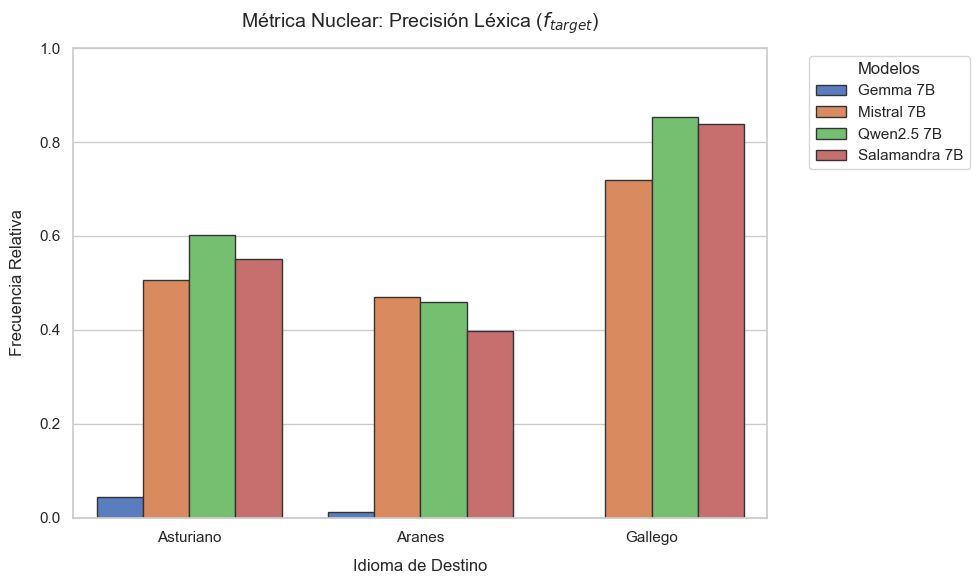

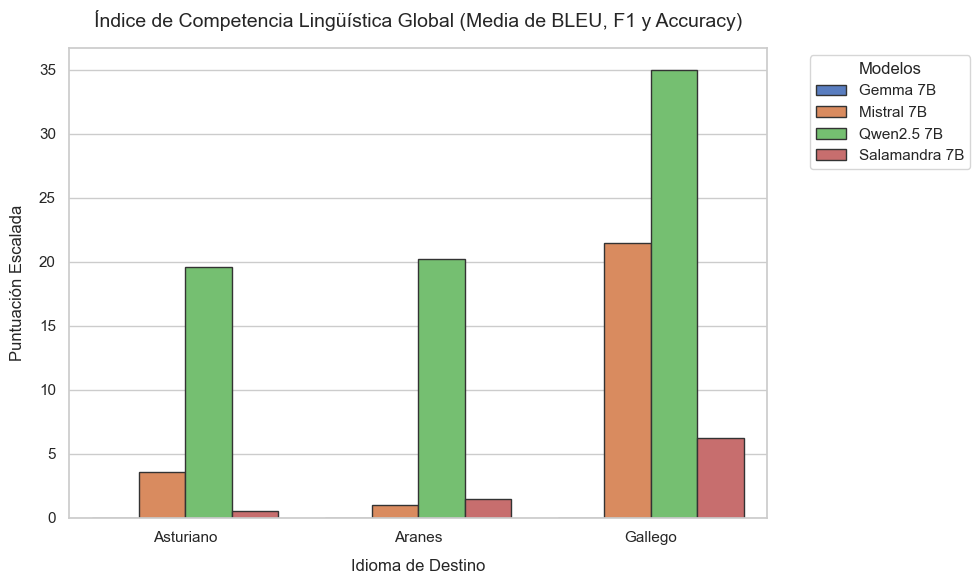

In [31]:
orden_idiomas = [ "asturiano", "aranes", "gallego"]


generar_grafico_flexible(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Métrica Nuclear: Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=orden_idiomas,    
    output_path="1_calidad_freq_target.png"
)


generar_grafico_flexible(
    datos_globales=resultados_base,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=orden_idiomas,     
    output_path="2_competencia_global.png"
)

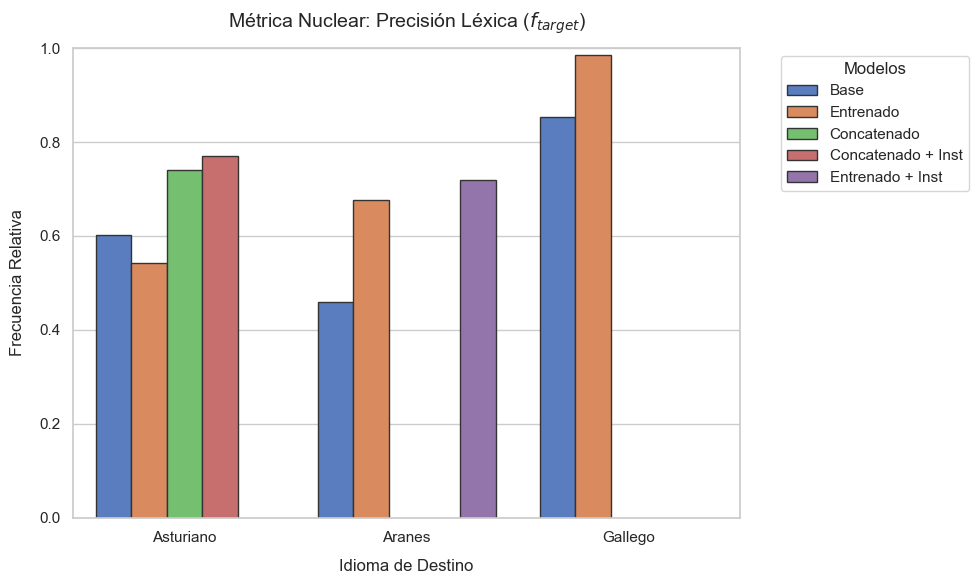

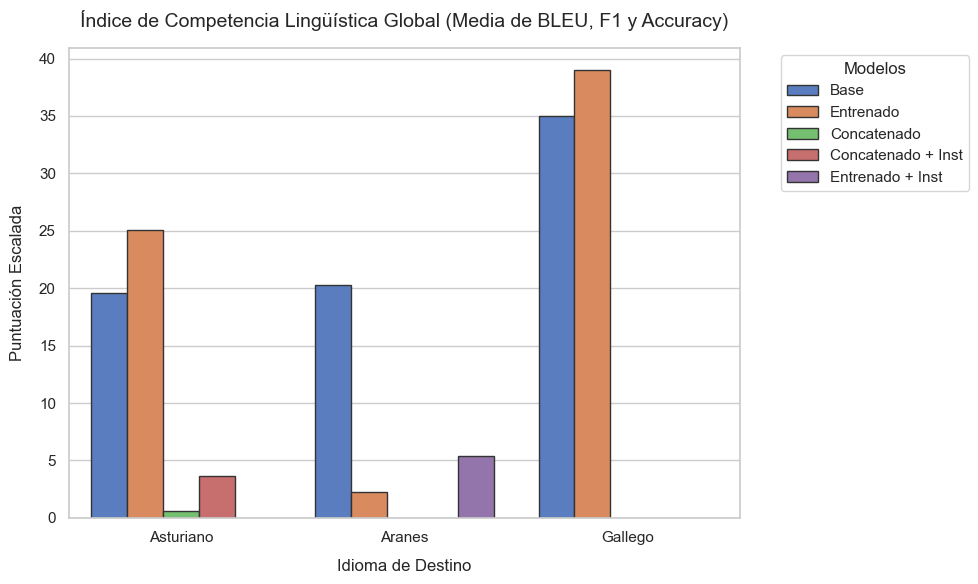

In [32]:
orden_idiomas = [ "asturiano", "aranes", "gallego"]


generar_grafico_flexible(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Métrica Nuclear: Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=orden_idiomas,    
    output_path="1_calidad_freq_target.png"
)


generar_grafico_flexible(
    datos_globales=resultados_qlora,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=orden_idiomas,     
    output_path="2_competencia_global.png"
)

In [33]:
import plotly.graph_objects as go
import pandas as pd

def generar_grafico_plotly(datos_globales, extractor, titulo="Comparativa", ylabel="Valor", 
                           ylim=None, idiomas_orden=None, output_path=None):
    records = []
    
    # 1. Extracción de los datos (Misma lógica robusta que ya tienes)
    for lengua, models_dict in datos_globales.items():
        for modelo, tareas in models_dict.items():
            val = None
            
            if callable(extractor):
                try: val = extractor(tareas)
                except Exception: val = None
            elif isinstance(extractor, tuple):
                tarea = extractor[0]
                metrica = extractor[1]
                sub_metrica = extractor[2] if len(extractor) > 2 else None
                if tarea in tareas and "media" in tareas[tarea]:
                    m_val = tareas[tarea]["media"].get(metrica)
                    val = m_val.get(sub_metrica) if (sub_metrica and isinstance(m_val, dict)) else m_val
            elif isinstance(extractor, str):
                tareas_encontradas = [t for t, c in tareas.items() if "media" in c and extractor in c["media"]]
                if len(tareas_encontradas) > 1:
                    raise ValueError(f"Métrica ambigua '{extractor}' en: {tareas_encontradas}. Usa una tupla.")
                elif len(tareas_encontradas) == 1:
                    val = tareas[tareas_encontradas[0]]["media"].get(extractor)
            
            if isinstance(val, (int, float)):
                records.append({
                    "Idioma": lengua.strip().title(),
                    "Modelo": modelo,
                    "Valor": round(val, 4)
                })
                
    if not records:
        print("No se encontraron datos para graficar.")
        return
        
    df = pd.DataFrame(records)
    
    # Determinar el orden del eje X (Idiomas)
    orden_x = [i.strip().title() for i in idiomas_orden] if idiomas_orden else sorted(df["Idioma"].unique())
    modelos = df["Modelo"].unique()
    
    # Paleta de colores chula y académica (Muted/Cool tech)
    colores = ["#4682B4", "#20B2AA", "#87CEFA", "#778899"] 
    color_map = {modelo: colores[i % len(colores)] for i, modelo in enumerate(modelos)}
    
    fig = go.Figure()
    
    # En Plotly, las barras agrupadas se añaden creando una "traza" por cada Modelo
    for modelo in modelos:
        df_modelo = df[df["Modelo"] == modelo]
        
        # Sincronizar con el orden de idiomas establecido
        valores_ordenados = []
        for idm in orden_x:
            fila = df_modelo[df_modelo["Idioma"] == idm]
            valores_ordenados.append(fila["Valor"].values[0] if not fila.empty else 0)
            
        fig.add_trace(go.Bar(
            name=modelo,
            x=orden_x,
            y=valores_ordenados,
            marker_color=color_map[modelo],
            marker_line_color="rgb(50,50,50)",
            marker_line_width=1,
            hovertemplate=f"<b>{modelo}</b><br>Idioma: %{{x}}<br>{ylabel}: %{{y}}<extra></extra>"
        ))
    
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=16, color="rgb(30,30,30)"), x=0.01),
        xaxis=dict(
            title=dict(text="Idioma de Destino", font=dict(size=13)), 
            tickfont=dict(size=12)
        ),
        yaxis=dict(
            title=dict(text=ylabel, font=dict(size=13)), 
            tickfont=dict(size=12), 
            gridcolor="rgb(235,235,235)"
        ),
        barmode='group',
        plot_bgcolor="white",
        paper_bgcolor="white",
        legend=dict(title="Modelos", bordercolor="rgb(220,220,220)", borderwidth=1),
        margin=dict(l=60, r=40, t=60, b=60),
        width=900,
        height=500 
    )
    
    # Ajustar límites del eje Y si se solicitan
    if ylim:
        fig.update_yaxes(range=[ylim[0], ylim[1]])
        
    # Guardar archivo si se especifica ruta
    if output_path:
        if output_path.endswith('.html'):
            fig.write_html(output_path)
        else:
            # Requiere pip install kaleido para exportar a png/pdf estático desde plotly
            fig.write_image(output_path, scale=2)
            
    fig.show()

In [34]:
orden_idiomas = ["asturiano", "aranes", "gallego"]

# Gráfica 1: Tu métrica nuclear directa
generar_grafico_plotly(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Métrica Nuclear: Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=orden_idiomas,
    output_path="1_calidad_freq_target.html" # Puedes guardarlo en HTML interactivo
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
generar_grafico_plotly(
    datos_globales=resultados_base,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=orden_idiomas,
    output_path="2_competencia_global_avanzado.html"
)

In [35]:
orden_idiomas = ["asturiano", "aranes", "gallego"]

# Gráfica 1: Tu métrica nuclear directa
generar_grafico_plotly(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Métrica Nuclear: Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=orden_idiomas,
    output_path="1_calidad_freq_target.html" # Puedes guardarlo en HTML interactivo
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
generar_grafico_plotly(
    datos_globales=resultados_qlora,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=orden_idiomas,
    output_path="2_competencia_global_avanzado.html"
)